In [2]:
"""
steps for LDA for different languages:
1. import everything and define BCTs
2. figure out how to break up segments for LDA to run on in each language (Stopwords ISO)
3.
"""


'\nsteps for LDA for different languages:\n1. import everything and define BCTs\n2. figure out how to break up segments for LDA to run on in each language (Stopwords ISO)\n3.\n'

In [12]:
# Imports

!pip install datasets scikit-learn nltk stopwordsiso
import re
import time
import json
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import stopwordsiso



 # log into HF
#from google.colab import userdata
#import os
#os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN') ### if you have one please use your hugging face token if not please comment out

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# Save BCTs as dictionary -> final BCTs looked at by native speakers but it's not actually that simple
BCT_FORMS = {
    'en': {
        'black':  ['black'],
        'white':  ['white'],
        'red':    ['red'],
        'green':  ['green'],
        'yellow': ['yellow'],
        'blue':   ['blue'],
        'brown':  ['brown'],
        'orange': ['orange'],
        'pink':   ['pink'],
        'purple': ['purple'],
        'gray':   ['gray', 'grey'],
    },
    'fr': {
        'black':  ['noir', 'noire', 'noirs', 'noires'],
        'white':  ['blanc', 'blanche', 'blancs', 'blanches'],
        'red':    ['rouge', 'rouges'],
        'green':  ['vert', 'verte', 'verts', 'vertes'],
        'yellow': ['jaune', 'jaunes'],
        'blue':   ['bleu', 'bleue', 'bleus', 'bleues'],
        'brown':  ['marron', 'marrons'],
        'orange': ['orange', 'oranges'],
        'pink':   ['rose', 'roses'],
        'purple': ['violet', 'violette', 'violets', 'violettes'],
        'gray':   ['gris', 'grise', 'grises'],
    },
    'es': {
        'black':  ['negro', 'negra', 'negros', 'negras'],
        'white':  ['blanco', 'blanca', 'blancos', 'blancas'],
        'red':    ['rojo', 'roja', 'rojos', 'rojas'],
        'green':  ['verde', 'verdes'],
        'yellow': ['amarillo', 'amarilla', 'amarillos', 'amarillas'],
        'blue':   ['azul', 'azules'],
        'brown':  ['marrón', 'marrones'],
        'orange': ['naranja', 'naranjas'],
        'pink':   ['rosa', 'rosas'],
        'purple': ['morado', 'morada', 'morados', 'moradas'],
        'gray':   ['gris', 'grises'],
    },
    'ca': {
        'black':  ['negre', 'negra', 'negres'],
        'white':  ['blanc', 'blanca', 'blancs', 'blanques'],
        'red':    ['vermell', 'vermella', 'vermells', 'vermelles'],
        'green':  ['verd', 'verda', 'verds', 'verdes'],
        'yellow': ['groc', 'groga', 'grocs', 'grogues'],
        'blue':   ['blau', 'blava', 'blaus', 'blaves'],
        'brown':  ['marró', 'marrons'],
        'orange': ['taronja', 'taronges'],
        'pink':   ['rosa', 'roses'],
        'purple': ['morat', 'morada', 'morats', 'morades'],
        'gray':   ['gris', 'grisa', 'grisos', 'grises'],
    },
}

# link language to wikipedia dumps:
WIKI_CONFIG = {
    'en': '20231101.en',
    'fr': '20231101.fr',
    'es': '20231101.es',
    'ca': '20231101.ca',
}


# get list of stopwords -> (non-meaning making words e.g. of, a, on)

STOPWORDSISO_CODE = {'en': 'en', 'fr': 'fr', 'es': 'es', 'ca': 'ca'}

def get_stopwords(lang):
    return list(stopwordsiso.stopwords(STOPWORDSISO_CODE[lang]))




In [6]:
""" set parameters:
max number of instances for the colour,
minimum sentence length -> 20 characters not words,
absolutely maximum number of articles for it to look through,
shuffle buffer to keep order of things random
random seed so it can be reproduced
show progress every 500 so I know it's not stuck
number of topics for the lda to show. chose 15 as I knew I would be doing it by hand,
 so long enough to hopefully see patterns but not long enough that its impossible to do by hand.
"""
RUN_MODE = 'full'
if RUN_MODE == 'full':
    N_SENTENCES_TARGET = 1500
    MIN_SENTENCE_LEN = 20
    ARTICLE_SCAN_CAP = 400_000
    SHUFFLE_BUFFER = 2000
    RANDOM_SEED = 42
    PROGRESS_EVERY = 500
    N_TOPICS = 15
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE!r} (expected'full')")

print(f"RUN_MODE={RUN_MODE!r}  |  N_SENTENCES_TARGET={N_SENTENCES_TARGET}  "
      f"ARTICLE_SCAN_CAP={ARTICLE_SCAN_CAP}  N_TOPICS={N_TOPICS}")



RUN_MODE='full'  |  N_SENTENCES_TARGET=1500  ARTICLE_SCAN_CAP=400000  N_TOPICS=15


In [7]:
"""
This is for counting the proper nouns:
(1) build alternative forms of colors e.g, rojo, roja, rojos into one color_form
(2) take any of the alt forms and see if there are any capitals after it
(3) take any of the alt forms and see if there is a capital for the word before.
(4) return them if this function is called.
"""
def build_cap_patterns(color_forms):
    # Build expression catching 'Color Capitalized' and 'Capitalized Color'.
    alt = "|".join(re.escape(f) for f in color_forms)
    color_then_cap = re.compile(rf"\b(?i:{alt}) [A-ZÀ-Ý][\wÀ-ÿ]+", re.UNICODE)
    cap_then_color = re.compile(rf"\b[A-ZÀ-Ý][\wÀ-ÿ]+ (?i:{alt})\b", re.UNICODE)
    return color_then_cap, cap_then_color

"""
this cell only works for cap_then_color because for color then cap we know this is not the beginning of a sentence
(1) get rid of spaces at the beginning or end of a sentence
(2) for the cap_then_color check whether the capital occurs at NOT the first 'position' or is NOT the first character in the sentence
(3) If that is true then it is a proper noun.
(4) search the colour then cap as well.
"""
def is_proper_noun_flagged(raw_sentence, cap_then_color_re, color_then_cap_re):
    stripped = raw_sentence.strip()
    for m in cap_then_color_re.finditer(stripped):
        if m.start() != 0:
            return True
    return bool(color_then_cap_re.search(stripped))

#build a dictionary to hold (per language) the functions to search all colours for proper nouns
CAP_PATTERNS = {
    lang: {
        color: build_cap_patterns(forms)
        for color, forms in colors.items()
    }
    for lang, colors in BCT_FORMS.items()
}





In [8]:
"""Collect all the sentences that qualify!
(1) define funcrtion with parameters decided earleir
(2) call ditionary for cap patterns
(3) show where we are looking (Wikipedia) per language
(4) shuffle articles so we don't search alphabetically
(5) split by newline, ., !, ? and check the character count of the sentence.
(6) print out progress as it searches
(7) run on each language
"""

def collect_all_colors(lang, n_target=N_SENTENCES_TARGET,
                        min_len=MIN_SENTENCE_LEN,
                        scan_cap=ARTICLE_SCAN_CAP,
                        shuffle_buffer=SHUFFLE_BUFFER,
                        seed=RANDOM_SEED,
                        progress_every=PROGRESS_EVERY):

    color_forms = BCT_FORMS[lang]
    cap_patterns = CAP_PATTERNS[lang]


    results = {color: [] for color in color_forms}
    counts_rejected_short = 0
    articles_scanned = 0

    config_name = WIKI_CONFIG[lang]
    print(f"[{lang}] Loading stream: wikimedia/wikipedia/{config_name}")
    dataset = load_dataset("wikimedia/wikipedia", config_name, split="train", streaming=True)
    dataset = dataset.shuffle(seed=seed, buffer_size=shuffle_buffer)

    def all_full():
        return all(len(v) >= n_target for v in results.values())

    start = time.time()
    for article in dataset:
        articles_scanned += 1
        text = article['text']
        raw_sentences = re.split(r'[.!?\n]+', text)

        for raw in raw_sentences:
            if len(raw) <= min_len:
                counts_rejected_short += 1
                continue
            lower = raw.lower()

            for color, forms in color_forms.items():
                if len(results[color]) >= n_target:
                    continue

                hit = any(re.search(rf"\b{re.escape(f)}\b", lower) for f in forms)
                if not hit:
                    continue

                color_then_cap_re, cap_then_color_re = cap_patterns[color]
                flagged = is_proper_noun_flagged(raw, cap_then_color_re, color_then_cap_re)

                results[color].append({"text": lower, "is_proper_noun": flagged})

        if articles_scanned % progress_every == 0:
            fill = {c: len(v) for c, v in results.items()}
            elapsed = time.time() - start
            print(f"[{lang}] scanned={articles_scanned} elapsed={elapsed:.0f}s fill={fill}")

        if all_full() or articles_scanned >= scan_cap:
            break

    print(f"[{lang}] DONE. articles_scanned={articles_scanned}, "
          f"rejected_short={counts_rejected_short}")
    for color, sents in results.items():
        n_flagged = sum(s["is_proper_noun"] for s in sents)
        print(f"    {color:8s}: n={len(sents):5d}  proper_noun_flagged={n_flagged}")

    return results, {"articles_scanned": articles_scanned, "lang": lang}



In [9]:
results_en, meta_en = collect_all_colors('en')

[en] Loading stream: wikimedia/wikipedia/20231101.en


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results_fr, meta_fr = collect_all_colors('fr')

[fr] Loading stream: wikimedia/wikipedia/20231101.fr


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

[fr] scanned=500 elapsed=3s fill={'black': 51, 'white': 64, 'red': 44, 'green': 18, 'yellow': 6, 'blue': 11, 'brown': 0, 'orange': 4, 'pink': 9, 'purple': 6, 'gray': 4}
[fr] scanned=1000 elapsed=5s fill={'black': 125, 'white': 135, 'red': 68, 'green': 29, 'yellow': 12, 'blue': 22, 'brown': 0, 'orange': 7, 'pink': 21, 'purple': 7, 'gray': 10}
[fr] scanned=1500 elapsed=9s fill={'black': 170, 'white': 202, 'red': 97, 'green': 40, 'yellow': 26, 'blue': 35, 'brown': 2, 'orange': 9, 'pink': 26, 'purple': 9, 'gray': 10}
[fr] scanned=2000 elapsed=11s fill={'black': 227, 'white': 262, 'red': 140, 'green': 55, 'yellow': 37, 'blue': 37, 'brown': 4, 'orange': 16, 'pink': 37, 'purple': 9, 'gray': 23}
[fr] scanned=2500 elapsed=13s fill={'black': 303, 'white': 324, 'red': 171, 'green': 61, 'yellow': 38, 'blue': 41, 'brown': 5, 'orange': 17, 'pink': 46, 'purple': 9, 'gray': 26}
[fr] scanned=3000 elapsed=14s fill={'black': 349, 'white': 385, 'red': 209, 'green': 66, 'yellow': 42, 'blue': 49, 'brown': 6

In [ ]:
results_es, meta_es = collect_all_colors('es')

[es] Loading stream: wikimedia/wikipedia/20231101.es
[es] scanned=500 elapsed=14s fill={'black': 187, 'white': 217, 'red': 276, 'green': 168, 'yellow': 47, 'blue': 136, 'brown': 19, 'orange': 23, 'pink': 88, 'purple': 16, 'gray': 34}
[es] scanned=1000 elapsed=27s fill={'black': 420, 'white': 520, 'red': 529, 'green': 296, 'yellow': 108, 'blue': 267, 'brown': 28, 'orange': 39, 'pink': 164, 'purple': 34, 'gray': 68}
[es] scanned=1500 elapsed=42s fill={'black': 725, 'white': 794, 'red': 818, 'green': 459, 'yellow': 168, 'blue': 413, 'brown': 43, 'orange': 61, 'pink': 257, 'purple': 49, 'gray': 102}
[es] scanned=2000 elapsed=55s fill={'black': 1046, 'white': 1159, 'red': 1011, 'green': 547, 'yellow': 216, 'blue': 482, 'brown': 52, 'orange': 78, 'pink': 405, 'purple': 56, 'gray': 126}
[es] scanned=2500 elapsed=69s fill={'black': 1367, 'white': 1500, 'red': 1257, 'green': 690, 'yellow': 284, 'blue': 564, 'brown': 70, 'orange': 119, 'pink': 505, 'purple': 70, 'gray': 156}
[es] scanned=3000 el

In [ ]:
results_ca, meta_ca = collect_all_colors('ca')

[ca] Loading stream: wikimedia/wikipedia/20231101.ca
[ca] scanned=500 elapsed=3s fill={'black': 23, 'white': 27, 'red': 12, 'green': 21, 'yellow': 4, 'blue': 7, 'brown': 4, 'orange': 1, 'pink': 3, 'purple': 0, 'gray': 3}
[ca] scanned=1000 elapsed=5s fill={'black': 46, 'white': 37, 'red': 18, 'green': 30, 'yellow': 13, 'blue': 11, 'brown': 6, 'orange': 3, 'pink': 10, 'purple': 0, 'gray': 4}
[ca] scanned=1500 elapsed=7s fill={'black': 80, 'white': 80, 'red': 29, 'green': 55, 'yellow': 19, 'blue': 16, 'brown': 8, 'orange': 5, 'pink': 19, 'purple': 1, 'gray': 4}
[ca] scanned=2000 elapsed=11s fill={'black': 162, 'white': 115, 'red': 35, 'green': 66, 'yellow': 22, 'blue': 20, 'brown': 8, 'orange': 7, 'pink': 27, 'purple': 3, 'gray': 6}
[ca] scanned=2500 elapsed=13s fill={'black': 202, 'white': 135, 'red': 40, 'green': 78, 'yellow': 23, 'blue': 35, 'brown': 10, 'orange': 7, 'pink': 31, 'purple': 3, 'gray': 8}
[ca] scanned=3000 elapsed=15s fill={'black': 238, 'white': 166, 'red': 98, 'green': 

In [ ]:
# collecte results in a .json so we don't have to rerun everything if the colab disconnects.
ALL_RESULTS = {'en': results_en, 'fr': results_fr, 'es': results_es, 'ca': results_ca}
ALL_META = {'en': meta_en, 'fr': meta_fr, 'es': meta_es, 'ca': meta_ca}

with open('bct_sentences_checkpoint.json', 'w', encoding='utf-8') as f:
    json.dump(ALL_RESULTS, f, ensure_ascii=False)

with open('bct_meta_checkpoint.json', 'w', encoding='utf-8') as f:
    json.dump(ALL_META, f, ensure_ascii=False, indent=2)

print("Checkpoint saved: bct_sentences_checkpoint.json, bct_meta_checkpoint.json")



Checkpoint saved: bct_sentences_checkpoint.json, bct_meta_checkpoint.json


In [ ]:
# Fit the LDA
def fit_lda_for(sentences_with_flags, lang, n_topics=N_TOPICS, max_features=500, seed=RANDOM_SEED):
    """
    Fit one LDA model on ALL sentences for a color/language (proper nouns
    included). is_proper_noun is included but just used to count how many proper nouns there are
    """
    texts = [s["text"] for s in sentences_with_flags]
    n_proper = sum(1 for s in sentences_with_flags if s["is_proper_noun"])

    if len(texts) < n_topics * 2:
        return None  # not enough data to fit meaningfully

    sw = get_stopwords(lang)
    vectorizer = CountVectorizer(stop_words=sw, max_features=max_features)
    X = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=seed)
    lda.fit(X)

    words = vectorizer.get_feature_names_out()
    topics = []
    for topic in lda.components_:
        top_words = [words[j] for j in topic.argsort()[-10:]][::-1]
        topics.append(top_words)

    return {"n_docs": len(texts), "n_proper_noun_flagged": n_proper, "topics": topics}

In [ ]:
LDA_RESULTS = {}  # GET RESULTS

for lang, color_dict in ALL_RESULTS.items():
    for color, sentences in color_dict.items():
        key = (lang, color)
        out = fit_lda_for(sentences, lang=lang)
        LDA_RESULTS[key] = out
        status = "OK" if out else "SKIPPED (too few docs)"
        n_docs = out["n_docs"] if out else 0
        n_proper = out["n_proper_noun_flagged"] if out else 0
        pct = f"{100 * n_proper / n_docs:.0f}%" if out and n_docs else "n/a"
        print(f"{lang}/{color:8s} -> {status} (n={n_docs}, proper_noun_flagged={n_proper} [{pct}])")



en/black    -> OK (n=1500, proper_noun_flagged=687 [46%])
en/white    -> OK (n=1500, proper_noun_flagged=464 [31%])
en/red      -> OK (n=1500, proper_noun_flagged=955 [64%])
en/green    -> OK (n=1500, proper_noun_flagged=741 [49%])
en/yellow   -> OK (n=1500, proper_noun_flagged=391 [26%])
en/blue     -> OK (n=1500, proper_noun_flagged=885 [59%])
en/brown    -> OK (n=1500, proper_noun_flagged=778 [52%])
en/orange   -> OK (n=1500, proper_noun_flagged=730 [49%])
en/pink     -> OK (n=1500, proper_noun_flagged=464 [31%])
en/purple   -> OK (n=1500, proper_noun_flagged=534 [36%])
en/gray     -> OK (n=1500, proper_noun_flagged=553 [37%])
fr/black    -> OK (n=1500, proper_noun_flagged=226 [15%])
fr/white    -> OK (n=1500, proper_noun_flagged=177 [12%])
fr/red      -> OK (n=1500, proper_noun_flagged=326 [22%])
fr/green    -> OK (n=1500, proper_noun_flagged=340 [23%])
fr/yellow   -> OK (n=1500, proper_noun_flagged=499 [33%])
fr/blue     -> OK (n=1500, proper_noun_flagged=319 [21%])
fr/brown    ->

In [1]:
import csv

rows = []
for (lang, color), out in LDA_RESULTS.items():
    if out is None:
        continue
    n_docs = out["n_docs"]
    n_proper = out["n_proper_noun_flagged"]
    pct_proper = round(100 * n_proper / n_docs, 1) if n_docs else None
    for topic_idx, top_words in enumerate(out["topics"]):
        rows.append({
            "lang": lang,
            "color": color,
            "n_docs": n_docs,
            "n_proper_noun_flagged": n_proper,
            "pct_proper_noun_flagged": pct_proper,
            "topic_idx": topic_idx + 1,
            "top_words": ", ".join(top_words),
        })

with open('bct_lda_topics.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=["lang", "color", "n_docs", "n_proper_noun_flagged",
                                            "pct_proper_noun_flagged", "topic_idx", "top_words"])
    writer.writeheader()
    writer.writerows(rows)

print(f"Wrote {len(rows)} topic rows to bct_lda_topics.csv")



NameError: name 'LDA_RESULTS' is not defined

In [ ]:
# Summary: proper_noun count + percentage

summary_rows = []
for lang in ALL_RESULTS:
    for color in BCT_FORMS[lang]:
        out = LDA_RESULTS.get((lang, color))
        if out is None:
            continue
        n_docs = out["n_docs"]
        n_proper = out["n_proper_noun_flagged"]
        pct_proper = round(100 * n_proper / n_docs, 1) if n_docs else None
        summary_rows.append({
            "lang": lang,
            "color": color,
            "n_docs": n_docs,
            "n_proper_noun_flagged": n_proper,
            "pct_proper_noun_flagged": pct_proper,
        })

summary_rows_sorted = sorted(summary_rows, key=lambda r: r["pct_proper_noun_flagged"] or 0, reverse=True)

print(f"{'lang':4s} {'color':8s} {'n_docs':7s} {'n_proper':9s} {'pct':6s}")
for r in summary_rows_sorted:
    print(f"{r['lang']:4s} {r['color']:8s} {r['n_docs']:7d} "
          f"{r['n_proper_noun_flagged']:9d} {r['pct_proper_noun_flagged']:.1f}%")

with open('bct_proper_noun_summary.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=["lang", "color", "n_docs",
                                            "n_proper_noun_flagged", "pct_proper_noun_flagged"])
    writer.writeheader()
    writer.writerows(summary_rows)

print("\nWrote bct_proper_noun_summary.csv")


lang color    n_docs  n_proper  pct   
en   red         1500       955 63.7%
en   blue        1500       885 59.0%
ca   pink        1500       786 52.4%
en   brown       1500       778 51.9%
en   green       1500       741 49.4%
en   orange      1500       730 48.7%
en   black       1500       687 45.8%
es   pink        1500       685 45.7%
en   gray        1500       553 36.9%
en   purple      1500       534 35.6%
fr   purple      1500       504 33.6%
fr   yellow      1500       499 33.3%
es   red         1500       469 31.3%
en   white       1500       464 30.9%
en   pink        1500       464 30.9%
ca   green       1500       457 30.5%
es   white       1500       409 27.3%
fr   pink        1500       407 27.1%
en   yellow      1500       391 26.1%
es   green       1500       367 24.5%
fr   green       1500       340 22.7%
fr   red         1500       326 21.7%
fr   blue        1500       319 21.3%
ca   blue        1500       292 19.5%
es   blue        1500       271 18.1%
fr   orange

In [16]:
## THIS IS FOR AFTER THE LABELLING
import pandas as pd
df = pd.read_csv("bct_lda_topics_labelling_v3.csv")

# strip spaces off every label so "Identity " == "Identity"
for c in ['Primary label','Secondary Label','Denonatitive/Connotative','color','lang']:
    df[c] = df[c].astype(str).str.strip()

# combine both concept columns, lowercase, to match loosely
concept = (df['Primary label'].fillna('') + ' ' + df['Secondary Label'].fillna('')).str.lower()
df['idrace'] = concept.str.contains('identity') | concept.str.contains('social movement')

bw = df[df['color'].str.lower().isin(['black','white'])]
print("raw counts:\n", bw.groupby('lang')['idrace'].sum())
print("\nproportion of black+white topics:\n", bw.groupby('lang')['idrace'].mean())

raw counts:
 lang
ca     4
en    14
es     6
fr     3
Name: idrace, dtype: int64

proportion of black+white topics:
 lang
ca    0.133333
en    0.466667
es    0.200000
fr    0.100000
Name: idrace, dtype: float64


In [11]:
assoc = bw[bw['denonatitive or connotative'].str.lower().str.contains('connotative|association', na=False)]
print(assoc.groupby('lang')['idrace'].mean())

NameError: name 'bw' is not defined

In [ ]:
import pandas as pd
df = pd.read_csv("bct_lda_topics_labelling_v1_renamed.csv")
df = df.apply(lambda c: c.str.strip() if c.dtype=="object" else c)   # kill trailing spaces everywhere

concept = (df['primary'].fillna('') + ' ' + df['secondary'].fillna('')).str.lower()
df['color'] = df['color'].str.lower()

concepts = ['identity','social movement','ecology','belief and ritual','warnings',
            'conflict','politics','power structures','death','food','life experiences','arts']

rows = []
for k in concepts:
    df['hit'] = concept.str.contains(k)
    tab = df.groupby(['color','lang'])['hit'].mean().unstack()   # proportion per colour×lang
    tab['concept'] = k
    rows.append(tab)

matrix = pd.concat(rows)
matrix.to_csv("colour_concept_matrix.csv")
print(matrix.round(3))

lang       ca     en     es     fr   concept
color                                       
black   0.200  0.467  0.267  0.067  identity
blue    0.067  0.000  0.000  0.000  identity
brown   0.000  0.067  0.000  0.067  identity
gray    0.000  0.000  0.000  0.000  identity
green   0.000  0.000  0.067  0.000  identity
...       ...    ...    ...    ...       ...
pink    0.067  0.067  0.000  0.133      arts
purple  0.000  0.133  0.000  0.267      arts
red     0.333  0.000  0.000  0.267      arts
white   0.067  0.200  0.067  0.533      arts
yellow  0.133  0.333  0.067  0.067      arts

[132 rows x 5 columns]


In [ ]:
"""
Build two colour-concept matrices from the LDA topic-labelling CSV.

Table 1 (ALL topics):      denominator = every topic of that colour x language (15 each)
Table 2 (ASSOCIATION only): restricted to connotative/association topics; denominator =
                            association topics of that colour x language.

Outputs, per table: a PROPORTION matrix and a raw COUNT matrix (rows = concept x colour,
columns = language). Counts matter because small denominators make proportions jumpy.

Run: set CSV_PATH, then `python build_colour_concept_matrices.py`
"""
import pandas as pd

CSV_PATH = "bct_lda_topics_labelling_v1_renamed.csv"     # <-- change to your file

# ---- load and whitespace-proof everything (this was the trailing-space bug) ----
df = pd.read_csv(CSV_PATH)
df = df.apply(lambda c: c.str.strip() if c.dtype == "object" else c)

# ---- normalise the fields we filter on ----
df['color'] = df['color'].str.lower()
df['lang']  = df['lang'].str.lower()

# combined concept text (primary + secondary), lowercased, so matching is loose
concept_txt = (df['primary'].fillna('') + ' ' + df['secondary'].fillna('')).str.lower()

# register: association = value contains 'assoc' or 'connot'; else treated as occurrence/denotation
reg = df['denonatitive or connotative'].fillna('').str.lower()
df['is_assoc'] = reg.str.contains('assoc') | reg.str.contains('connot')

# ---- concepts to score (edit/extend as you like; must be lowercase substrings) ----
CONCEPTS = ['identity', 'social movement', 'ecology', 'belief and ritual', 'warnings',
            'conflict', 'politics', 'power structures', 'death', 'food',
            'life experiences', 'arts', 'space', 'named entity',
            'colour co-occurrence', 'physical description']

COLOURS = ['black','white','red','green','yellow','blue','brown','orange','pink','purple','gray']
LANGS   = ['en','fr','es','ca']


def build_matrix(data, concept_txt_series):
    """Return (proportion_df, count_df) with rows=(concept,colour), cols=lang."""
    prop_rows, count_rows = {}, {}
    # denominator = number of topics per colour x lang in THIS subset
    denom = data.groupby(['color','lang']).size().unstack().reindex(index=COLOURS, columns=LANGS)
    for k in CONCEPTS:
        hit = concept_txt_series.str.contains(k, regex=False)
        num = data.assign(hit=hit).groupby(['color','lang'])['hit'].sum().unstack()
        num = num.reindex(index=COLOURS, columns=LANGS)
        prop = (num / denom)
        for col in COLOURS:
            prop_rows[(k, col)]  = prop.loc[col]
            count_rows[(k, col)] = num.loc[col]
    prop_df  = pd.DataFrame(prop_rows).T
    count_df = pd.DataFrame(count_rows).T
    prop_df.index.names  = ['concept','colour']
    count_df.index.names = ['concept','colour']
    return prop_df.round(3), count_df.astype('Int64')


# ---- Table 1: ALL topics ----
prop_all, count_all = build_matrix(df, concept_txt)
prop_all.to_csv("matrix_ALL_proportion.csv")
count_all.to_csv("matrix_ALL_counts.csv")

# ---- Table 2: ASSOCIATION only ----
assoc = df[df['is_assoc']].copy()
assoc_txt = concept_txt[df['is_assoc']]
prop_assoc, count_assoc = build_matrix(assoc, assoc_txt)
prop_assoc.to_csv("matrix_ASSOCIATION_proportion.csv")
count_assoc.to_csv("matrix_ASSOCIATION_counts.csv")

# ---- quick sanity print ----
print("=== ASSOCIATION-only: how many association topics per colour x lang (denominators) ===")
print(assoc.groupby(['color','lang']).size().unstack().reindex(index=COLOURS, columns=LANGS).fillna(0).astype(int))
print("\n=== ASSOCIATION-only proportions (a few key concepts) ===")
for k in ['identity','ecology','belief and ritual','warnings']:
    print(f"\n-- {k} --")
    print(prop_assoc.loc[k])

print("\nSaved 4 files: matrix_ALL_[proportion|counts].csv and matrix_ASSOCIATION_[proportion|counts].csv")


=== ASSOCIATION-only: how many association topics per colour x lang (denominators) ===
lang    en  fr  es  ca
color                 
black   10   1   6   4
white    4   1   2   3
red      2   4   3   3
green    2   4   1   5
yellow   3   1   3   1
blue     1   2   2   4
brown    1   1   0   0
orange   0   2   1   1
pink     0   2   0   1
purple   0   0   6   3
gray     0   0   0   0

=== ASSOCIATION-only proportions (a few key concepts) ===

-- identity --
lang      en   fr     es     ca
colour                         
black   0.60  1.0  0.667  0.750
white   0.75  0.0  1.000  0.333
red     0.00  0.0  0.000  0.333
green   0.00  0.0  0.000  0.000
yellow  0.00  0.0  0.000  0.000
blue    0.00  0.0  0.000  0.250
brown   1.00  1.0    NaN    NaN
orange   NaN  0.0  0.000  0.000
pink     NaN  0.0    NaN  0.000
purple   NaN  NaN  0.000  0.000
gray     NaN  NaN    NaN    NaN

-- ecology --
lang     en    fr   es   ca
colour                     
black   0.0  0.00  0.0  0.0
white   0.0  0.00  0.0  

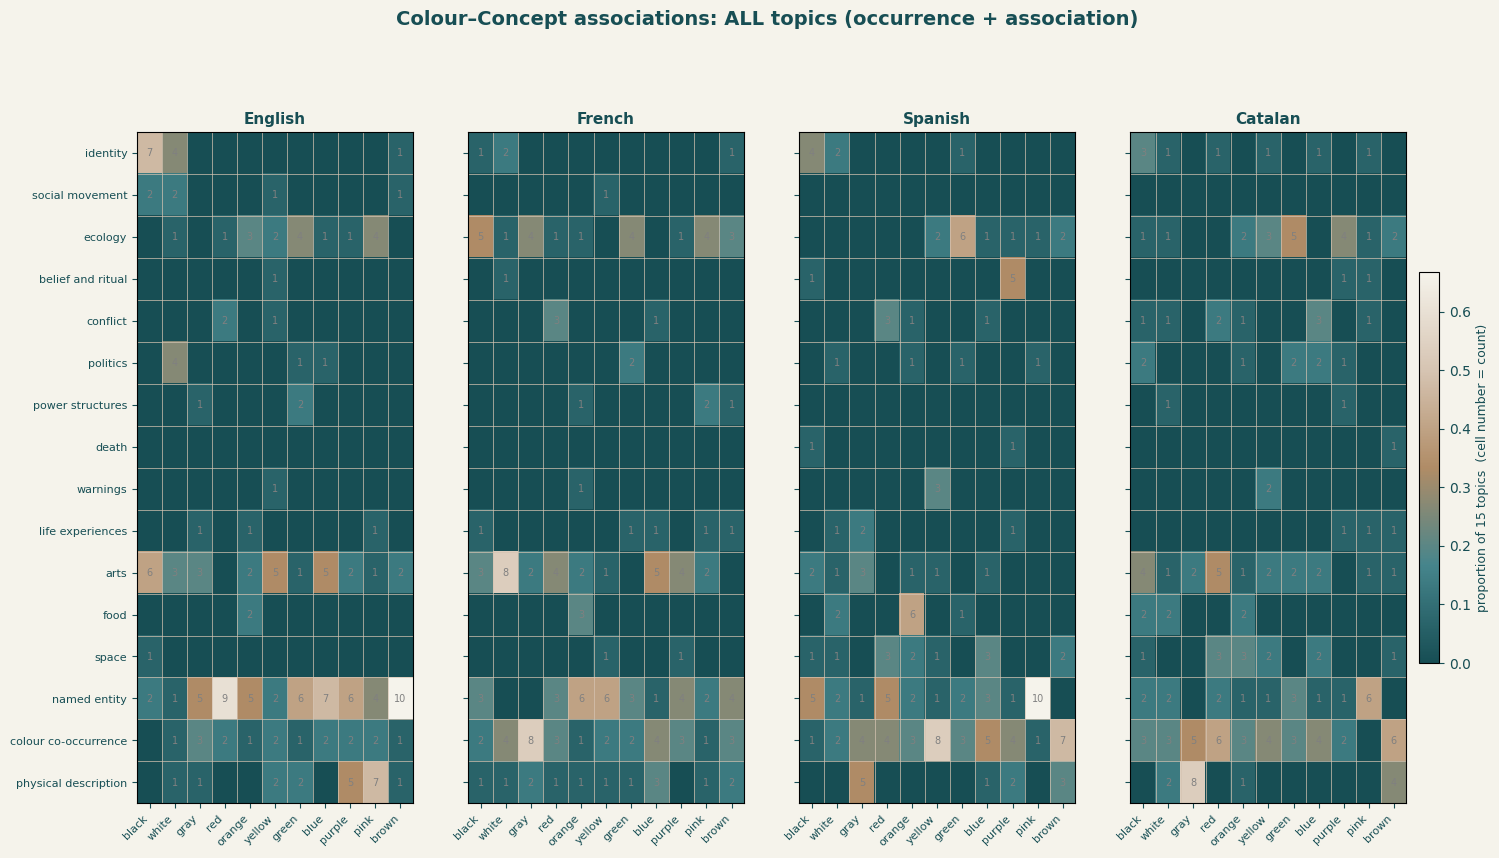

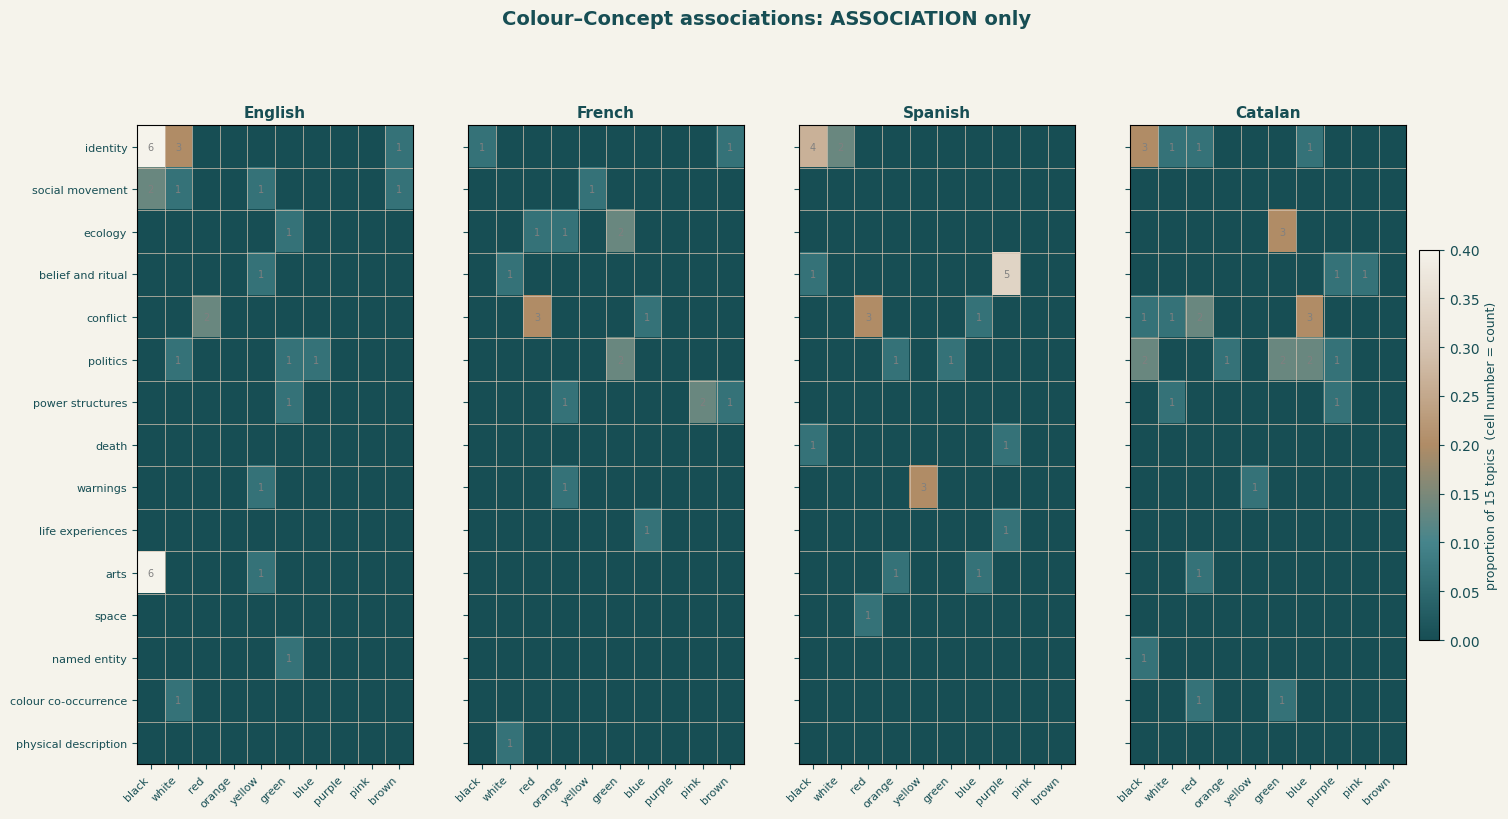

In [3]:
# ============================================================
# Colour–Concept heatmaps (Colab-ready)
#
# BEFORE RUNNING, CHECK TWO THINGS:
# 1. FILE PATHS (bottom of this cell): point them at your CSVs.
#    In Colab, uploaded files usually live in /content/.
# 2. is_counts FLAG (bottom): use
#       False  if the CSV holds PROPORTIONS (decimals like 0.33)
#       True   if the CSV holds COUNTS      (whole numbers like 5)
#    (ALL_proportion -> False ;  ASSOCIATION_counts -> True)
#
# N_TOPICS must match your LDA (15). It converts counts <-> proportions.
# ============================================================

import pandas as pd, numpy as np
import matplotlib.pyplot as plt          # no 'Agg' backend -> plots show inline in Colab
from matplotlib.colors import LinearSegmentedColormap

N_TOPICS = 15
LANGS = ['en', 'fr', 'es', 'ca']
LANG_NAME = {'en': 'English', 'fr': 'French', 'es': 'Spanish', 'ca': 'Catalan'}
COLOUR_ORDER = ['black','white','gray','red','orange','yellow','green','blue','purple','pink','brown']
# meaningful concepts first, then structural/noise
CONCEPT_ORDER = ['identity','social movement','ecology','belief and ritual','conflict','politics',
                 'power structures','death','warnings','life experiences','arts','food','space',
                 'named entity','colour co-occurrence','physical description']

# ------------------- STYLE: background + font -------------------
BG = '#F5F3EB'

TEXT = '#174E54'

plt.rcParams['figure.facecolor'] = BG
plt.rcParams['axes.facecolor'] = BG
plt.rcParams['savefig.facecolor'] = BG

# ------------------- STYLE: custom colormap -------------------
# Sequential ramp through the full palette, low to high.
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'palette_full',
    ['#174E54', '#46858c', '#b08c66', '#d6c4b2', '#F5F3EB']
)


def load(path, is_counts):
    df = pd.read_csv(path)
    df['concept'] = df['concept'].astype(str).str.strip()
    df['colour']  = df['colour'].astype(str).str.strip()
    for l in LANGS:
        df[l] = pd.to_numeric(df[l], errors='coerce').fillna(0.0)   # blanks -> 0
    out = {}
    for l in LANGS:
        if is_counts:
            cnt = df[l].values;            prop = cnt / N_TOPICS
        else:
            prop = df[l].values;           cnt  = np.round(prop * N_TOPICS)
        out[(l, 'count')] = cnt
        out[(l, 'prop')]  = prop
    base = df[['concept', 'colour']].copy()
    return base, out


def grid(base, out, lang, kind):
    s = pd.Series(out[(lang, kind)], index=pd.MultiIndex.from_frame(base))
    m = s.unstack('colour')
    m = m.reindex(index=[c for c in CONCEPT_ORDER if c in m.index],
                  columns=[c for c in COLOUR_ORDER if c in m.columns])
    return m


def make_figure(path, is_counts, title, outpng=None, cmap=PALETTE_CMAP):
    base, out = load(path, is_counts)
    # shared axes: keep only concepts/colours that are non-zero somewhere
    tot = np.zeros(len(base))
    for l in LANGS:
        tot = tot + out[(l, 'count')]
    keep = base.assign(t=tot)
    live_con = [c for c in CONCEPT_ORDER if keep.loc[keep.concept == c, 't'].sum() > 0]
    live_col = [c for c in COLOUR_ORDER if keep.loc[keep.colour  == c, 't'].sum() > 0]
    vmax = max(out[(l, 'prop')].max() for l in LANGS) or 1

    fig, axes = plt.subplots(1, 4, figsize=(4.2 * 4, 0.42 * len(live_con) + 2), sharey=True)
    fig.patch.set_facecolor(BG)
    for ax, l in zip(axes, LANGS):
        ax.set_facecolor(BG)
        propm = grid(base, out, l, 'prop').reindex(index=live_con, columns=live_col).fillna(0)
        cntm  = grid(base, out, l, 'count').reindex(index=live_con, columns=live_col).fillna(0)
        im = ax.imshow(propm.values, cmap=cmap, vmin=0, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(live_col))); ax.set_xticklabels(live_col, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(live_con))); ax.set_yticklabels(live_con, fontsize=8)
        ax.set_title(LANG_NAME[l], fontsize=11, fontweight='bold', color=TEXT)
        for i in range(len(live_con)):
            for j in range(len(live_col)):
                c = cntm.values[i, j]
                if c > 0:
                    ax.text(j, i, f'{int(c)}', ha='center', va='center',
                            fontsize=7, color='#808080')
        ax.tick_params(colors=TEXT)
        ax.set_xticks(np.arange(-.5, len(live_col), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(live_con), 1), minor=True)
        ax.grid(which='minor', color='#d6c4b2', lw=0.5); ax.tick_params(which='minor', length=0)

    cbar = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
    cbar.set_label('proportion of 15 topics  (cell number = count)', fontsize=9, color=TEXT)
    cbar.ax.yaxis.set_tick_params(color=TEXT)
    plt.setp(cbar.ax.get_yticklabels(), color=TEXT)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02, color=TEXT)
    if outpng:
        fig.savefig(outpng, dpi=150, bbox_inches='tight', facecolor=BG)   # optional: saves a file too
    plt.show()                                              # shows inline in Colab


# ------------------- EDIT THESE TWO CALLS -------------------
make_figure('/content/matrix_ALL_proportion.csv', False,
            'Colour–Concept associations: ALL topics (occurrence + association)',
            outpng='/content/heatmap_ALL.png')

make_figure('/content/matrix_ASSOCIATION_counts.csv', True,
            'Colour–Concept associations: ASSOCIATION only',
            outpng='/content/heatmap_ASSOCIATION.png')